## Overview
The solution consists of 3 models contained in this notebook:
* install model - binary classifier predicting the probability of a user installing the app, trained on all labeled users,
* has events model - binary classifier predicting the probability of  a user having at least one ad revenue event, trained on labeled users which installed the app,
* ad revenue model - regression model predicting the logarithm of total ad revenue for a user, trained on labeled users which installed and had at least one revenue event.

The final score is the product of the two probabilities and the predicted value of the ad revenue.

This notebook has the following sections:
* imports & file handling,
* exploratory data analysis,
* install model training,
* has events & ad revenue models training,
* predictions.

## Imports & file handling

In [1]:
import numpy as np
import pandas as pd
import os
import gc
import matplotlib.pyplot as plt
import re
from collections import defaultdict
from itertools import product
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import average_precision_score, make_scorer
from lightgbm import LGBMClassifier, LGBMRegressor, early_stopping
from scipy.stats import spearmanr

pd.set_option('display.max_colwidth', 1000)

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/digital-turbine-ml-accelerator-ds-summit-2025/sample_submission.csv
/kaggle/input/competitions/digital-turbine-ml-accelerator-ds-summit-2025/kaggle_app_id_to_category_mapping.csv
/kaggle/input/competitions/digital-turbine-ml-accelerator-ds-summit-2025/kaggle_training_data.csv
/kaggle/input/competitions/digital-turbine-ml-accelerator-ds-summit-2025/kaggle_app_catalog_training_data.csv
/kaggle/input/competitions/digital-turbine-ml-accelerator-ds-summit-2025/kaggle_candidates.csv
/kaggle/input/competitions/digital-turbine-ml-accelerator-ds-summit-2025/kaggle_app_catalog_candidates.csv


In [2]:
# competition files
train_path = '/kaggle/input/competitions/digital-turbine-ml-accelerator-ds-summit-2025/kaggle_training_data.csv'
app_train_path = '/kaggle/input/competitions/digital-turbine-ml-accelerator-ds-summit-2025/kaggle_app_catalog_training_data.csv'
candidate_path = '/kaggle/input/competitions/digital-turbine-ml-accelerator-ds-summit-2025/kaggle_candidates.csv'
app_candidate_path = '/kaggle/input/competitions/digital-turbine-ml-accelerator-ds-summit-2025/kaggle_app_catalog_candidates.csv'
mapping_path = '/kaggle/input/competitions/digital-turbine-ml-accelerator-ds-summit-2025/kaggle_app_id_to_category_mapping.csv'
submission_path = '/kaggle/input/competitions/digital-turbine-ml-accelerator-ds-summit-2025/sample_submission.csv'

path_list = [train_path, app_train_path, candidate_path, app_candidate_path, 
             mapping_path, submission_path]

In [3]:
# check row counts in all provided files
for path in path_list:

    filename = path.rsplit('/', 1)[-1]

    with open(path) as file:
        n_rows = len(file.readlines())
    
    print (f'Number of data rows in {filename}: {n_rows - 1}')

Number of data rows in kaggle_training_data.csv: 2027832
Number of data rows in kaggle_app_catalog_training_data.csv: 521500
Number of data rows in kaggle_candidates.csv: 1005306
Number of data rows in kaggle_app_catalog_candidates.csv: 257979
Number of data rows in kaggle_app_id_to_category_mapping.csv: 1362101
Number of data rows in sample_submission.csv: 10000


Upon inspection of kaggle_training_data.csv, it was discovered that it does not load into pandas correctly due to commas separating events, which should be loaded into a single column. The file is processed and the contents saved to a new location after the necessary corrections. Two more files are created, one containing rows with installs and one containing rows with events.

In [4]:
# paths to the new files
fixed_train_path = '/kaggle/working/fixed_training_data.csv'
install_train_path = '/kaggle/working/install_training_data.csv'
event_train_path = '/kaggle/working/event_training_data.csv'

with open(train_path, 'r', encoding = 'utf-8', newline = '') as fin, \
     open(fixed_train_path, 'w', encoding = 'utf-8', newline = '') as foutfixed, \
     open(install_train_path, 'w', encoding = 'utf-8', newline = '') as foutinstall, \
     open(event_train_path, 'w', encoding = 'utf-8', newline = '') as foutevent:

    header = fin.readline()
    foutfixed.write(header)
    foutinstall.write(header)
    foutevent.write(header)

    for line in fin:

        # '1' after the second comma of the line means the user installed
        first_comma = line.find(',')
        second_comma = line[first_comma+1:].find(',')

        if line[first_comma+second_comma+2] == '1':

            # the only square brackets in the line
            lb = line.find('[')
            rb = line.find(']')
        
            if rb-lb != 1: # there are events in this line

                # get and fix events by substituting ',' with ';'
                events = line[lb:rb+1]
                events_fixed = re.sub(r'[\s\\"]+', '',events.replace(',',';'))

                # if events, line is saved to each of the files
                foutfixed.write(line[:lb] + events_fixed + line[rb+1:])
                foutinstall.write(line[:lb] + events_fixed + line[rb+1:])
                foutevent.write(line[:lb] + events_fixed + line[rb+1:])

            else: # no events

                # only save to the main and install files
                foutfixed.write(line)
                foutinstall.write(line)

        else: # no install
            
            # only save to the main file
            foutfixed.write(line)

# check row counts in all new files
for path in [fixed_train_path, install_train_path, event_train_path]:

    filename = path.rsplit('/', 1)[-1]

    with open(path) as file:
        n_rows = len(file.readlines())
    
    print (f'Number of data rows in {filename}: {n_rows - 1}')

Number of data rows in fixed_training_data.csv: 2027832
Number of data rows in install_training_data.csv: 345538
Number of data rows in event_training_data.csv: 21261


## Exploratory data analysis

In [5]:
sample_train_df = pd.read_csv(fixed_train_path, nrows = 5)
print(f'Number of cols: {len(sample_train_df.columns)}')
sample_train_df.head(2)

Number of cols: 1594


,hashed_aaid,install_timestamp,install,events,uwu_clicks_banner_action_adventure_d1,uwu_clicks_banner_action_adventure_d28,uwu_clicks_banner_action_adventure_d3,uwu_clicks_banner_action_adventure_d7,uwu_clicks_banner_audio_video_d1,uwu_clicks_banner_audio_video_d28,...,ohh_quarters_active_weather_d7,ohh_total_hours_active_d1,ohh_total_hours_active_d28,ohh_total_hours_active_d3,ohh_total_hours_active_d7,ohh_total_quarters_active_d1,ohh_total_quarters_active_d28,ohh_total_quarters_active_d3,ohh_total_quarters_active_d7,d
0,001b3e80ec5bc8bad0fd1094d14cbbf02321924ac393fa9e9d5fd660fe716ebd,NaN,0.0,[],NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-05
1,017dd3016bd6ec79a2c082a969c43441a7838d893c710ed65cabe6225057465b,NaN,0.0,[],NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,10.0,NaN,3.0,NaN,19.0,NaN,4.0,2025-11-05


In [6]:
non_feature_cols = ['hashed_aaid', 'install_timestamp', 'events', 'd', 'install']
feature_cols = [col for col in sample_train_df.columns if col not in non_feature_cols]

In [7]:
sample_candidate_df = pd.read_csv(candidate_path, nrows = 5)
print(f'Number of cols: {len(sample_candidate_df.columns)}')
sample_candidate_df.head(2)

Number of cols: 1591


,hashed_aaid,uwu_clicks_banner_action_adventure_d1,uwu_clicks_banner_action_adventure_d28,uwu_clicks_banner_action_adventure_d3,uwu_clicks_banner_action_adventure_d7,uwu_clicks_banner_audio_video_d1,uwu_clicks_banner_audio_video_d28,uwu_clicks_banner_audio_video_d3,uwu_clicks_banner_audio_video_d7,uwu_clicks_banner_board_card_d1,...,ohh_quarters_active_weather_d7,ohh_total_hours_active_d1,ohh_total_hours_active_d28,ohh_total_hours_active_d3,ohh_total_hours_active_d7,ohh_total_quarters_active_d1,ohh_total_quarters_active_d28,ohh_total_quarters_active_d3,ohh_total_quarters_active_d7,ad_revenue
0,000ab063d80a13385223378b456367a9896368d267cbf9a14c7ddff5a7141401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,11.0,3.0,4.0,NaN,22.0,8.0,10.0,NaN
1,00a6cbfa1d396e0154307c8633be209fc35fdd9b3e99b740712a8410d79a2501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
candidate_non_feature_cols = ['hashed_aaid', 'ad_revenue']
candidate_feature_cols = [col for col in sample_candidate_df.columns if col not in candidate_non_feature_cols]
print(candidate_feature_cols == feature_cols) 
# missing install & timestamp, events and date as expected, ad_revenue present instead, features agree

True


Check how many missing values there are in each feature column and what fraction of values is missing in each row per column family (uwu, ohh, bar, foo). This will inform missing value handling - if an entire family of columns is missing values, it is assumed to be due to lack of coverage of the corresponding product.

In [9]:
# file too big to load all at once, done in chunks instead
chunksize = 100_000
non_null = pd.Series(0, index = feature_cols, dtype = 'Int32') # stores non null counts
fam_info_chunks = []

family_cols = {
    k: [c for c in feature_cols if c.startswith(k)]
    for k in ['uwu', 'ohh', 'bar', 'foo']
}

types = defaultdict(lambda: 'float32')
types.update({'hashed_aaid':'str', 'events':'str', 'd':'str', 
              'install':'Int32', 'install_timestamp':'str'})

for chunk in pd.read_csv(fixed_train_path, dtype = types, chunksize = chunksize):
    
    non_null += chunk[feature_cols].notna().sum().astype('Int32') # per col sums over chunks

    fam_info = chunk[['hashed_aaid', 'd', 'install_timestamp', 'events', 'install']].copy()
    for k, cols in family_cols.items():
        fam_info[f'{k}_non_null_frac'] = (1.0 - chunk[cols].isna().mean(axis=1)).astype('float32')
    fam_info_chunks.append(fam_info)

    del chunk, fam_info
    gc.collect()

non_null_summary_df = pd.DataFrame({"non_null_count": non_null})
non_null_frac_df = pd.concat(fam_info_chunks, ignore_index=True)

The non_null_summary_df generated above was consulted ad-hoc at various stages, its summary can be seen in the figure below - over 300 completely empty columns. Additionally to its main purpose, the non_null_frac_df will be used for further EDA and feature enrichment.

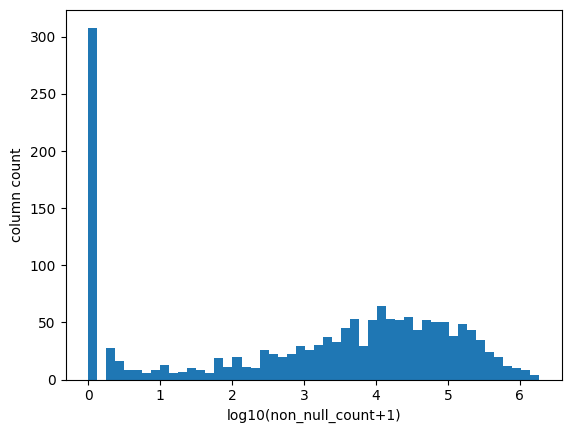

In [10]:
# histogram showing the number of non-null values across columns
plt.figure()
plt.hist(np.log10(non_null_summary_df['non_null_count']+1), bins=50)
plt.xlabel('log10(non_null_count+1)')
plt.ylabel('column count')
plt.show()

In [11]:
print(f'hashed_aaid null count: {non_null_frac_df['hashed_aaid'].isna().sum()}')
non_null_frac_df['hashed_aaid'].value_counts()

hashed_aaid null count: 0


hashed_aaid
22df00fc299c653f6f570d9f1d9dc4141e5aec2935211f150c6f049baf5b96f0    3
e9340b626d7a77e3bba23c87fa744191e49abfb7c07f28c2c76eaec42e25c1e2    3
93cd2412124036985cf36f2dd158f971e3372f2fc961acf4d1ee1fce07f62718    3
8c8950c5911b06b48ce4f909f1f401f3775d692bdfd8c06d9229dbbc188850cc    3
baffab1fe8106745feea2df6b45792e2c27fc9ff9eb04d66ec5c930c1649d494    3
                                                                   ..
93fac1295207869e8edab22d6d5bd5914aff62eb27d0d2271d07bbe38687794f    1
91dcaf7641e94998e364994217fb2a17aedc8b5679f46a5c5cd0af93ef953940    1
8f51cbef5888e32d3bc71575eafe6dc71e192535a0739a72e52d0cb9f8710477    1
8d95dced4383088bea75eefd68b65fff6d631093806cb74e883e858bf078d947    1
a111a34416efe5b79a77fd49a71f39cf6c05608f8d266442a74db90a451ad184    1
Name: count, Length: 2015002, dtype: int64

In [12]:
non_null_frac_df.loc[non_null_frac_df['hashed_aaid'] == 'e9340b626d7a77e3bba23c87fa744191e49abfb7c07f28c2c76eaec42e25c1e2']

,hashed_aaid,d,install_timestamp,events,install,uwu_non_null_frac,ohh_non_null_frac,bar_non_null_frac,foo_non_null_frac
50245,e9340b626d7a77e3bba23c87fa744191e49abfb7c07f28c2c76eaec42e25c1e2,2025-11-05,NaN,[],0,0.086486,0.121901,0.0,0.044643
1244586,e9340b626d7a77e3bba23c87fa744191e49abfb7c07f28c2c76eaec42e25c1e2,2025-10-13,2025-10-10T12:23:03.000Z,[],1,0.037838,0.033058,0.0,0.000000
1377620,e9340b626d7a77e3bba23c87fa744191e49abfb7c07f28c2c76eaec42e25c1e2,2025-10-29,NaN,[],0,0.037838,0.101240,0.0,0.026786


In [13]:
non_null_frac_df.loc[non_null_frac_df['hashed_aaid'] == '23f1702a759662305525b22e26f2aa0cd4816db53b2178eab1dafc8a38737948']

,hashed_aaid,d,install_timestamp,events,install,uwu_non_null_frac,ohh_non_null_frac,bar_non_null_frac,foo_non_null_frac
887190,23f1702a759662305525b22e26f2aa0cd4816db53b2178eab1dafc8a38737948,2025-10-18,2025-10-15T01:18:30.000Z,[{timestamp:2025-10-17T02:26:19.000Z;value_usd:0.07749893822;name:ad_revenue}],1,0.048649,0.051653,0.0,0.035714
993092,23f1702a759662305525b22e26f2aa0cd4816db53b2178eab1dafc8a38737948,2025-10-17,2025-10-14T04:19:14.000Z,[{timestamp:2025-10-17T02:26:19.000Z;value_usd:0.07749893822;name:ad_revenue}],1,0.027027,0.000000,0.0,0.017857


In [14]:
print((non_null_frac_df.groupby(['hashed_aaid', 'd']).size() != 1).sum()) # no repeats

0


hashed_aaids are not unique identifiers. A user can have multiple entries corresponding to different dates and can have an install / set of events in more than one of these entries. Features differ between the entries. The approach taken here is to keep only one row per hashed_aaid, according to the following logic:
* if there are no entries with installs associated with a hashed_aaid, keep the latest entry,
* if there is one entry with an install, keep that entry,
* if there are two entries with installs, keep the one with more events (and the latest one if there is a draw)

In [15]:
repeating_ids = (non_null_frac_df.loc[non_null_frac_df['hashed_aaid'].duplicated(keep=False), 
                 'hashed_aaid'].unique().tolist()) # keep=False marks all duplicates as True
print(f'Number of repeating IDs: {len(repeating_ids)}')

Number of repeating IDs: 12787


In [16]:
repeating_df = (non_null_frac_df.loc[non_null_frac_df['hashed_aaid'].isin(repeating_ids),
                ['hashed_aaid', 'install', 'events', 'd']]) # df with repeating IDs

non_null_frac_df.drop(columns = ['install_timestamp', 'events'], inplace = True)

installs_per_aaid = repeating_df.groupby('hashed_aaid')['install'].sum()

two_install_ids = installs_per_aaid.index[installs_per_aaid == 2].tolist()
one_install_ids = installs_per_aaid.index[installs_per_aaid == 1].tolist()
zero_install_ids = installs_per_aaid.index[installs_per_aaid == 0].tolist()

print(f'IDs with 2 installs: {len(two_install_ids)}')
print(f'IDs with 1 install: {len(one_install_ids)}')
print(f'IDs with 0 installs: {len(zero_install_ids)}')

# this column will first order by len(events) then by date when sorted
repeating_df['len_events_and_d'] = (repeating_df['events'].str.len().astype(str).str.zfill(6)
                                    + repeating_df['d'])

# each keep df contains hashed_aaid and d
keep0 = (repeating_df.loc[repeating_df['hashed_aaid'].isin(zero_install_ids)]
         .groupby('hashed_aaid', as_index = False)['d'].max()) # max d for each hashed_aaid
keep1 = (repeating_df.loc[(repeating_df['hashed_aaid'].isin(one_install_ids)) &
         (repeating_df['install'] == 1.0), ['hashed_aaid', 'd']].reset_index(drop = True))
# max len_events_and_d for each hashed_aaid
keep2 = (repeating_df.loc[repeating_df['hashed_aaid'].isin(two_install_ids)]
         .groupby('hashed_aaid', as_index = False)['len_events_and_d'].max()) 
keep2['d'] = keep2['len_events_and_d'].str[6:] # get d back
keep2.drop(columns = ['len_events_and_d'], inplace = True)
keep = pd.concat([keep0, keep1, keep2], ignore_index = True)
repeats_to_drop_df = (repeating_df.merge(keep, on = ['hashed_aaid', 'd'], how = 'left', indicator = True)
                      .loc[lambda x: x['_merge'] == 'left_only', ['hashed_aaid', 'd']]) # left anti join

IDs with 2 installs: 722
IDs with 1 install: 2289
IDs with 0 installs: 9776


In [17]:
# drop hashed_aaid repeats - left anti join
non_null_frac_df = (non_null_frac_df 
                    .merge(repeats_to_drop_df, on = ['hashed_aaid', 'd'], how = 'left',indicator = True)
                    .loc[lambda x: x['_merge'] == 'left_only', :].drop(columns = ['_merge']))

print(f'hashed_aaid null count: {non_null_frac_df['hashed_aaid'].isna().sum()}')
non_null_frac_df['hashed_aaid'].value_counts()

hashed_aaid null count: 0


hashed_aaid
ffd84572732180351702bea868b6e575c80c4171400dc45a88b14d23b2b4c7e1    1
001b3e80ec5bc8bad0fd1094d14cbbf02321924ac393fa9e9d5fd660fe716ebd    1
017dd3016bd6ec79a2c082a969c43441a7838d893c710ed65cabe6225057465b    1
02022901a4c2be4761b34ce20078de32c4810e70115f08a8f6413675f20d514a    1
026f07923dd4c277b259a5eff1afa98014607549c55a63b88cd3ae6eca1293ca    1
                                                                   ..
0b3db95d66ad5530c2238a1a9b70ad7d3136624269e73f40e219b1714cfdf82a    1
09ea09c8b98dc8aa2f325d2297111d6658519fc2eb43a73b6bc7232503bb1cf9    1
09b1690b179bbcb0bf92c86846fa3342e11d33dc7560e5ea4d88e1e6971f2a21    1
09ab59f195e1079d1d2e64b35178f5b16b808bcd4e9c02c125b2f2b8d1d840b2    1
098a40c8b66a2901e06184b1453df31d0baba85eee032a99d5b537c1e84d1f44    1
Name: count, Length: 2015002, dtype: int64

In [18]:
# print(f'install_timestamp null count: {non_null_frac_df['install_timestamp'].isna().sum()}')
# non_null_frac_df['install_timestamp'].value_counts()

In [19]:
# print(f'events null count: {non_null_frac_df['events'].isna().sum()}')
# non_null_frac_df['events'].value_counts()

In [20]:
print(f'install null count: {non_null_frac_df['install'].isna().sum()}')
non_null_frac_df['install'].value_counts() # label ratio for the first model

install null count: 0


install
0    1670189
1     344813
Name: count, dtype: Int64

In [21]:
del repeating_df
del installs_per_aaid
del two_install_ids
del one_install_ids
del zero_install_ids
del keep0
del keep1
del keep2
del non_null

gc.collect()

5744

## Install model training
The model uses the following features:
* impressions - proxy for exposure to ads of apps from different categories,
* total quarters active - proxy for overall user device engagement,
* ohh installs - directly related to the label (uwu installs removed based on empirical impact assessment),
* pseudo install time diff - directly related to the label,
* sum unique apps - proxy for an overall tendency to have apps,
* ad requests - proxy for ad exposure and time spent in apps,
* app counts - proxy for the tendency to have apps from different categories, extracted from the app catalog file.

This model (and the others) uses pre-install features where possible, computed by subtracting d3 features from the corresponding d7/d28/dX features. This is done following the logic that the candidate set contains users who could potentially install but have not done so yet, while the behaviour of users may be changing after the installation in a way which is informative. Those additional insights would not be available for the candidate users under these assumptions. Therefore, using post-install features could negatively impact generalisation capabilities of the model. The exception to this is features used to impute missing app count values - it is assumed that this does not have any noticeable effect.

The model also uses aggregate category 'rest' which combines (usually by summing) all categories apart from 'brain_game' and 'board_card'. This step was derived empirically, based on its impact on model performance.

In [22]:
types = defaultdict(lambda: 'float32')
types.update(
    {'hashed_aaid':'str', 'd':'str', 'install_timestamp':'str','install':'Int32', 'events':'str'}
)

install_metrics = ['uwu_impressions', 'total_quarters_active', 'ohh_installs', 
                   'pseudo_install_time_diff', 'uwu_sum_unique_apps', 'foo_ad_requests'] 
install_model_cols = ['hashed_aaid', 'install', 'd'] + [col for col in feature_cols if 
                ('reference' not in col) and (((not col.endswith('d1')) and 
                any(met in col for met in install_metrics)) or 
                # these colums are not directly used to predict installs, but to impute missing data from the app catalog          
                ('ohh_quarters_active' in col and 'd28' in col) or                   
                ('uwu_quarters_active' in col and 'd28' in col) or
                ('bar_uninstall' in col and 'd180' in col))]  
len(install_model_cols)

444

In [23]:
# too big to load all at once
chunksize = 500_000
install_model_chunks = []

pseudo_cols = [col for col in install_model_cols if 'pseudo' in col] # require different processing
metrics = ['uwu_impressions_banner', 'uwu_impressions_inter', 'ohh_installs', 'foo_ad_requests']
install_metrics = metrics[:] # for candidates file processing

for chunk in pd.read_csv(fixed_train_path, usecols = install_model_cols, 
                         dtype = types, chunksize = chunksize):
    
    # drop hashed_aaid repeats - left anti join
    chunk = (chunk.merge(repeats_to_drop_df, on = ['hashed_aaid', 'd'], 
                         how = 'left', indicator = True)
                  .loc[lambda x: x['_merge'] == 'left_only', :].drop(columns = ['_merge']))
    
    # add col family info 
    chunk = chunk.merge(non_null_frac_df.drop(columns = ['d', 'install']),
                        on = 'hashed_aaid', how = 'left')

    # rows where cols from a particular family are all nans (non_null_frac = 0) will be treated
    # as lacking the product coverage for that column family and nans will be substituted with -1
    # when non_null_frac != 0, missing values will be imputed with 0 (no instance of a particular
    # event), or a big number in the case of 'pseudo_install_time_diff', which seems more logical
    
    mask = chunk['ohh_non_null_frac'].ne(0.0)
    chunk.loc[mask, pseudo_cols] = chunk.loc[mask, pseudo_cols].fillna(999999.0)

    # the aggregate for pseudo_install_time_diff is taken to be the minimum value
    temp = [col for col in pseudo_cols if 'board_card' not in col and 'brain_game' not in col]
    chunk['ohh_pseudo_install_time_diff_rest_d56'] = chunk[temp].min(axis=1)
    chunk.drop(columns = temp, inplace = True)

    for k, cols in family_cols.items():
        # impute nans in columns belonging to the family with 0 for rows where it is not fully absent
        frac_col = f'{k}_non_null_frac'
        cols = [col for col in cols if col in chunk.columns]
        mask = chunk[frac_col].ne(0.0)
        chunk.loc[mask, cols] = chunk.loc[mask, cols].fillna(0.0)

    # aggregate columns for each metric and time window by summing all category contributions apart 
    # from 'brain_game' and 'board_card' - this considerably reduces the number of columns
    for metric in metrics:
        for dX in ['d3', 'd7', 'd28', 'd56', 'd60', 'd180']:
            cols_to_sum = [col for col in chunk.columns if (metric in col) and (dX in col) and 
                           ('brain_game' not in col) and ('board_card' not in col)]
            if len(cols_to_sum) > 0:
                agg_name = metric + '_rest_' + dX
                chunk[agg_name] = chunk[cols_to_sum].sum(axis = 1)
                if (metric != 'ohh_installs') or (dX != 'd28'):
                # ohh installs d28 are needed to impute missing values in app counts    
                    chunk.drop(columns = cols_to_sum, inplace = True)    

    install_model_chunks.append(chunk)
    del chunk
    gc.collect()

install_model_df = pd.concat(install_model_chunks, ignore_index=True)

In [24]:
install_model_df.head(2)

,hashed_aaid,install,uwu_impressions_banner_board_card_d28,uwu_impressions_banner_board_card_d3,uwu_impressions_banner_board_card_d7,uwu_impressions_banner_brain_game_d28,uwu_impressions_banner_brain_game_d3,uwu_impressions_banner_brain_game_d7,uwu_impressions_inter_board_card_d28,uwu_impressions_inter_board_card_d3,...,uwu_impressions_banner_rest_d28,uwu_impressions_inter_rest_d3,uwu_impressions_inter_rest_d7,uwu_impressions_inter_rest_d28,ohh_installs_rest_d3,ohh_installs_rest_d7,ohh_installs_rest_d28,foo_ad_requests_rest_d3,foo_ad_requests_rest_d7,foo_ad_requests_rest_d28
0,001b3e80ec5bc8bad0fd1094d14cbbf02321924ac393fa9e9d5fd660fe716ebd,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,017dd3016bd6ec79a2c082a969c43441a7838d893c710ed65cabe6225057465b,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [25]:
install_model_df['hashed_aaid'].value_counts() # no repeats

hashed_aaid
ffd84572732180351702bea868b6e575c80c4171400dc45a88b14d23b2b4c7e1    1
001b3e80ec5bc8bad0fd1094d14cbbf02321924ac393fa9e9d5fd660fe716ebd    1
017dd3016bd6ec79a2c082a969c43441a7838d893c710ed65cabe6225057465b    1
02022901a4c2be4761b34ce20078de32c4810e70115f08a8f6413675f20d514a    1
026f07923dd4c277b259a5eff1afa98014607549c55a63b88cd3ae6eca1293ca    1
                                                                   ..
0b3db95d66ad5530c2238a1a9b70ad7d3136624269e73f40e219b1714cfdf82a    1
09ea09c8b98dc8aa2f325d2297111d6658519fc2eb43a73b6bc7232503bb1cf9    1
09b1690b179bbcb0bf92c86846fa3342e11d33dc7560e5ea4d88e1e6971f2a21    1
09ab59f195e1079d1d2e64b35178f5b16b808bcd4e9c02c125b2f2b8d1d840b2    1
098a40c8b66a2901e06184b1453df31d0baba85eee032a99d5b537c1e84d1f44    1
Name: count, Length: 2015002, dtype: int64

In [26]:
install_model_df.isna().sum().sort_values()
# the missing values are the ones due to the lack of coverage

hashed_aaid                                0
install                                    0
bar_non_null_frac                          0
foo_non_null_frac                          0
uwu_impressions_banner_rest_d3             0
                                      ...   
bar_uninstalls_games_d180            1570497
bar_uninstalls_food_d180             1570497
bar_uninstalls_finance_d180          1570497
bar_uninstalls_entertainment_d180    1570497
bar_uninstalls_weather_d180          1570497
Length: 161, dtype: int64

In [27]:
# there are negative values in 'pseudo_install_time_diff' columns
# the approach is to offset them above zero
pseudo_cols = [col for col in install_model_df.columns if 'pseudo' in col] # now only contains 3 cols
min_pseudo_install_time_diff = install_model_df[pseudo_cols].min().min() # negative
install_model_df[pseudo_cols] = install_model_df[pseudo_cols] - min_pseudo_install_time_diff

In [28]:
# compute pre-install features
# leave sum_unique_apps as is, as these are not events but app counts
install_model_df[f'uwu_total_quarters_active_d28m3'] = (
    install_model_df[f'uwu_total_quarters_active_d28'] - install_model_df[f'uwu_total_quarters_active_d3']
)
install_model_df[f'uwu_total_quarters_active_d7m3'] = (
    install_model_df[f'uwu_total_quarters_active_d7'] - install_model_df[f'uwu_total_quarters_active_d3']
)
install_model_df[f'ohh_total_quarters_active_d28m3'] = (
    install_model_df[f'ohh_total_quarters_active_d28'] - install_model_df[f'ohh_total_quarters_active_d3']
)
install_model_df[f'ohh_total_quarters_active_d7m3'] = (
    install_model_df[f'ohh_total_quarters_active_d7'] - install_model_df[f'ohh_total_quarters_active_d3']
)
install_model_df.drop(columns = ['uwu_total_quarters_active_d28', 'uwu_total_quarters_active_d7', 
                                 'uwu_total_quarters_active_d3', 'ohh_total_quarters_active_d28', 
                                 'ohh_total_quarters_active_d7', 'ohh_total_quarters_active_d3'], inplace = True)

for category in ['rest', 'brain_game', 'board_card']:
    for metric in metrics:
        install_model_df[f'{metric}_{category}_d28m3'] = (
            install_model_df[f'{metric}_{category}_d28'] - install_model_df[f'{metric}_{category}_d3']
        )
        install_model_df[f'{metric}_{category}_d7m3'] = (
            install_model_df[f'{metric}_{category}_d7'] - install_model_df[f'{metric}_{category}_d3']
        )
        if (category == 'rest') or (metric != 'ohh_installs'):
            install_model_df.drop(columns = [f'{metric}_{category}_d28', f'{metric}_{category}_d7', 
                                             f'{metric}_{category}_d3'], inplace = True)
        else: # ohh installs d28 are needed to impute missing values in app counts 
            install_model_df.drop(columns = [f'{metric}_{category}_d7', f'{metric}_{category}_d3'], inplace = True)

The additional data from the app catalog file will be converted into app count per category features. However, this information is available only for certain users, so it needs to be imputed for the rest. This will be done by the means of least-squares fitting using five columns per category, selected based on perceived relevance.

In [29]:
# app counts per category will be added using this and the mapping df
app_train_df = pd.read_csv(app_train_path)
app_train_df.head(2)

,date,hashed_aaid,app_ids
0,2025-10-06,0543af3b4133f9369829cb49a93b461825192304af8b8c48f6dc47c6ea41936f,"843475,1576579,778011,224305,258177,929019,1092795,746013,220299,789323,962121,772808,1632326,1319170,255327,59909,58914,413173,1233447,753080,104910,220339,893205,1097076,776202,1000528,246320,789517,532989,710913,636710,337673,537455,93311,297761,772604,1196704,50998,773106,955894,737427,1647120,588605,373311,779061,109562,799903,250726,786786,148321,534143,191013,1302666,62373,124339,69292,752991,844355,701117,400373,492711,148869,1696419,763504,959482,861701,97128,288561,80744,362672,339340,99227,930049,94407,427316,824927,436319,1110355,603949,1768871,329427,737942,1782607,255493,802769,508798,849286,819299,802486,360122,786866,148320,891341,350411,850196,713723,964211,812318,969177,65639,549679,628987,1491524,95911,532520,308521,749230,1001425,1016277,815602,1504477,1328652,811423,1521457,220360,93948,896278,876983,101506,220129,275809,42838,257582,197184,982549,734037,148281,66156,1002469,144681,253235,255777,110141,736877,1473154,765086,897278,113947,142970,938150,843474,13..."
1,2025-10-06,1cafdb18c164fcc0dac4d96464da745e83714c6afad96a69e43130383eb7b375,"1196703,603949,257582,396604,1162629,50998,745738,827362,148281,373311,815602,255777,315716,851864,187940,405935,371280,1485612,955353,201821,1486098,148320,776202,460795,148321,1316720"


In [30]:
print(f'hashed_aaid null count: {app_train_df['hashed_aaid'].isna().sum()}')
app_train_df['hashed_aaid'].value_counts() # repeats

hashed_aaid null count: 0


hashed_aaid
e9454f5622867948bbb9705a5b56615ab03c046daf7166f3be8ce21175d65fbe    3
51e0b09bdedec05c5df70b6f3409bc4df6cada89a1cc775ada8b3fbed16243ac    3
432a28174b4a68000b00832508b854a9f3b4941c907c9825b49809e5d2d636ce    3
93cd2412124036985cf36f2dd158f971e3372f2fc961acf4d1ee1fce07f62718    3
e7733a5f60d8483a7b27790261f287c491c6232d18b0f603a15dc3c0b2e97b83    3
                                                                   ..
1eb860d9c84c139874a5ce54acf8a881ee165d6219bb03c9a457d20a5f997759    1
1b037c5b514a72e242f87b5d5b8982595149feeeb41d69bb4d22aee090c2802b    1
14b32edba83e9dbbb520e348b578b3e1fbe1337e34a0e8d453eaba371385219f    1
1039945294916cb92aa33cfdad3d5bc25d32a07ab82d5680b61c000622197598    1
7c9e68c782b1c4e6a1131db7130c5fe76f964d6c8272808ba6a03aec4ebe5c11    1
Name: count, Length: 517971, dtype: int64

In [31]:
print((app_train_df.groupby(['hashed_aaid', 'date']).size() != 1).sum()) # no repeats

0


In [32]:
# candidate app catalog
app_candidate_df = pd.read_csv(app_candidate_path)
app_candidate_df.head(2)

,hashed_aaid,app_ids
0,0006a243b077f27e9ccbbd1be1f3bf6b2fee424ae31995a862c6fac7eb7ee2d3,"985960,929019,781286,396604,1001425,815602,565928,851864,1761549,59909,1485612,372385,776202,955833,1138874,876983,246320,851278,930049,1122723,710913,275809,1196703,257582,603949,1196704,50998,148281,955894,373311,255777,108872,371280,1486098,148320,460795,148321,1316720"
1,000931c7a9451c7cb23988682e8d4f6e6cd1d946b8336f368aaa43fd862bccce,"300694,128794,549679,1092795,95911,799609,1801865,1623789,749230,1001425,788380,1310169,255327,1521457,811423,578604,797652,1233447,616628,220360,112154,933009,246320,896278,876983,1601471,220129,532989,981916,337673,297761,257582,772604,1734338,743109,712512,50998,1196704,978085,1003485,827362,148281,1692098,65881,1675010,144681,955894,914728,373311,255777,109562,72090,1274636,670724,772746,1566248,250726,1794391,211861,938150,148321,1316720,74851,396604,93174,750376,62090,1068506,1627063,701117,284821,899273,614232,122526,763504,946075,487058,1035842,67793,1485612,808730,80744,1684472,575586,101099,955774,93703,636709,1177618,57464,427316,1776985,93012,161897,1196703,1110355,995376,1742332,1130029,1681507,1759616,1013547,255493,788417,371280,654166,148320,799969,770715"


In [33]:
print(f'hashed_aaid null count: {app_candidate_df['hashed_aaid'].isna().sum()}')
app_candidate_df['hashed_aaid'].value_counts() # no repeats

hashed_aaid null count: 0


hashed_aaid
ffd8fe1c2bd24dd9f9d18226bbac5461210fa7ad529f3021160251f7bf17003c    1
0006a243b077f27e9ccbbd1be1f3bf6b2fee424ae31995a862c6fac7eb7ee2d3    1
000931c7a9451c7cb23988682e8d4f6e6cd1d946b8336f368aaa43fd862bccce    1
00137a58bf4ed9da9d9a8375d55cca4f1b34bf4e7d5976689b0838971908ebe2    1
00152c82175386720bcdd030bff7c0a0c470e5a1e21c7dd1342bb762141fc51a    1
                                                                   ..
00d4532df594876d1570da4ac6d3ab64cb2e77cdb6386b60bf151ed6bc1ada44    1
00c42f198457299804456b51b86e3e8578c6057f171e0279739523655d6405db    1
00c1c686a67634b9215d74bcfa2101236003cf149c22ab56795099f47ce5c8c7    1
00ab16d5cbc812a8eea10aff576360b3cf22133a6dca4bcf31ce677a8794adc4    1
00aad990523f6fc70fc3d40aa56b63d5fa8fa0a479079298111b036f4298f4c8    1
Name: count, Length: 257979, dtype: int64

In [34]:
mapping_df = pd.read_csv(mapping_path, dtype = {'app_id': 'Int32', 'category': 'str'})
mapping_df.head(2)

,app_id,category
0,1230410072,sport
1,530148,audio_video


In [35]:
# convert app string to a list
app_train_df['app_list'] = app_train_df['app_ids'].fillna('').str.split(',')
# convert the df into long format to get one id, date and app per row
id_app_long_df = app_train_df[['hashed_aaid', 'date', 'app_list']].explode('app_list').rename(columns={'app_list': 'app_id'})
id_app_long_df['app_id'] = pd.to_numeric(id_app_long_df['app_id'].str.strip(), errors='coerce').astype('Int32')
# add app categories
id_app_long_df = id_app_long_df.merge(mapping_df, on='app_id', how='left').dropna(subset=['category'])
id_app_long_df.head(2)

,hashed_aaid,date,app_id,category
0,0543af3b4133f9369829cb49a93b461825192304af8b8c48f6dc47c6ea41936f,2025-10-06,843475,productivity
1,0543af3b4133f9369829cb49a93b461825192304af8b8c48f6dc47c6ea41936f,2025-10-06,1576579,education


In [36]:
# flatten the id, date -> app mapping to get one row per id, date
cat_counts_df = (id_app_long_df.groupby(['hashed_aaid', 'date', 'category']).size()
                               .unstack(fill_value=0).add_prefix('app_count_').reset_index())
count_cols = [col for col in cat_counts_df.columns if col.startswith('app_count_')]
cat_counts_df[count_cols] = cat_counts_df[count_cols].astype('float32')
cat_counts_df['ts'] = pd.to_datetime(cat_counts_df['date'], errors='coerce') # to be used for merging
cat_counts_df.head(2)

category,hashed_aaid,date,app_count_action_adventure,app_count_audio_video,app_count_board_card,app_count_book,app_count_brain_game,app_count_business,app_count_casino,app_count_communication,...,app_count_productivity,app_count_shopping,app_count_social_networking,app_count_sport,app_count_strategy,app_count_transportation,app_count_travel,app_count_utilities,app_count_weather,ts
0,000014ee62128de8163a3da45885aee40630d85f60baa08b67e253f8483f4deb,2025-10-27,1.0,5.0,12.0,0.0,22.0,2.0,1.0,11.0,...,12.0,3.0,4.0,2.0,1.0,0.0,3.0,11.0,1.0,2025-10-27
1,000028b5541d80c5d1f3257cad42ff56705393d31132f69c7aa6425385833335,2025-10-11,1.0,5.0,4.0,0.0,4.0,0.0,1.0,5.0,...,4.0,2.0,2.0,0.0,1.0,0.0,1.0,7.0,1.0,2025-10-11


Because the timestamps do not exactly match between the dfs, merge_asof (a fuzzy time join) is used. It finds the closest row in cat_counts_df (by time) for each row in install_model_df, per hashed_aaid.

In [37]:
install_model_df['main_ts'] = pd.to_datetime(install_model_df['d'], format='%Y-%m-%d', errors='coerce')

install_model_df = pd.merge_asof(
    install_model_df.sort_values(['main_ts', 'hashed_aaid']),
    cat_counts_df.sort_values(['ts', 'hashed_aaid']),
    left_on='main_ts',
    right_on='ts',
    by='hashed_aaid',
    direction='nearest'
)

In [38]:
del install_model_chunks
del app_train_df
del id_app_long_df
del cat_counts_df

gc.collect()

17

In [39]:
# check if columns to be used for imputing missing app counts are present for each category 
categories = [col.replace('app_count_', '') for col in install_model_df.columns if 'app_count' in col]
for category in categories:
    condition = ((f'ohh_installs_{category}_d28' in install_model_df.columns) and 
                 (f'ohh_quarters_active_{category}_d28' in install_model_df.columns) and
                 (f'uwu_quarters_active_{category}_d28' in install_model_df.columns) and
                 (f'bar_uninstalls_{category}_d180' in install_model_df.columns))
    print(f'{category}: {condition}')

action_adventure: True
audio_video: True
board_card: True
book: True
brain_game: True
business: True
casino: True
communication: True
competitive_game: True
design: True
education: True
entertainment: True
finance: True
food: True
games: True
health: True
lifestyle: True
news: True
productivity: True
shopping: True
social_networking: True
sport: True
strategy: True
transportation: True
travel: True
utilities: True
weather: True


In [40]:
# want a separate column set for imputing missing app counts
install_model_df['uwu_sum_unique_apps_for_apps_d28'] = install_model_df['uwu_sum_unique_apps_d28']
# impute values missing due to the lack of coverage in the cols selected for the least-squares analysis
cols_for_apps = [col for col in install_model_df.columns if ('ohh_installs' in col and col.endswith('d28')) or
                ('ohh_quarters_active' in col) or ('uwu_quarters_active' in col) or
                ('bar_uninstalls' in col) or (col == 'uwu_sum_unique_apps_for_apps_d28')]
install_model_df[cols_for_apps] = install_model_df[cols_for_apps].fillna(-1.0)

In [41]:
# split dataset into 'train' and 'predict'
labeled = install_model_df['ts'].notna()
unlabeled = ~labeled

In [42]:
# least-squares fitting
for category in categories:
    cols_for_apps = [f'ohh_quarters_active_{category}_d28', f'uwu_quarters_active_{category}_d28', 
                 f'bar_uninstalls_{category}_d180', f'ohh_installs_{category}_d28',
                    'uwu_sum_unique_apps_for_apps_d28'] # features
    y_col = f'app_count_{category}' # label

    X = install_model_df.loc[labeled, cols_for_apps].to_numpy(dtype = np.float32, copy = False)
    y = install_model_df.loc[labeled, y_col].to_numpy(dtype = np.float32, copy = False)

    # add intercept
    X1 = np.column_stack([np.ones((X.shape[0], 1), dtype = X.dtype), X])

    # fit
    b, *_ = np.linalg.lstsq(X1, y)

    # predict set
    Xu = install_model_df.loc[unlabeled, cols_for_apps].to_numpy(dtype = np.float32, copy = False)
    Xu1 = np.column_stack([np.ones((Xu.shape[0], 1), dtype = Xu.dtype), Xu])

    # make predictions and assign to install_model_df
    pred = Xu1 @ b
    install_model_df.loc[unlabeled, y_col] = pred

    # uwu_sum_unique_apps_for_apps_d28 is used for all categories
    install_model_df.drop(columns = cols_for_apps[:-1], inplace = True)

In [43]:
install_model_df.drop(columns = ['date', 'ts', 'main_ts', 'uwu_sum_unique_apps_for_apps_d28'], inplace = True)

In [44]:
del labeled
del unlabeled
del pred
del X
del X1
del Xu
del Xu1

gc.collect()

0

In [45]:
# ensure non-negative app counts
# here there is no aggregation into 'rest' category - decision based on empirical testing
app_count_cols = [col for col in install_model_df.columns if 'app_count' in col]
install_model_df[app_count_cols] = install_model_df[app_count_cols].clip(lower=0)

In [46]:
# take log(x+1) of features - empirically established to be improving the fit
install_feature_cols = [col for col in install_model_df.columns if (col not in ['hashed_aaid', 'install', 'd']) and 
                        (not col.endswith('frac'))]
install_model_df[install_feature_cols] = np.log1p(install_model_df[install_feature_cols])

In [47]:
# impute all values missing due to the lack of coverage
install_model_df.fillna(-1.0, inplace = True)

In [48]:
# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    install_model_df.drop(columns = ['hashed_aaid', 'install', 'd',]),
    install_model_df['install'], 
    test_size = 0.05, 
    stratify = install_model_df['install'],
    random_state = 42
)

The modelling was done by first trying logistic regression and then moving onto LightGBM classifier. LightGBM was chosen because gradient boosting algorithms deliver very good results on tabular data, usually outperforming other models, often being faster and requiring less tuning than tabular neural networks. It was selected ahead of XGBoost as its leaf-wise growth can reach a strong model in fewer trees on big datasets, its histogram-first design is often faster and lighter on memory, which is a significant advantage on Kaggle, and it handles sparse features, which are very common in this dataset, very efficiently.

The commented out code below used a validation set to check 12 sets of hyperparameters. The chosen sets are 'best guesses' given the dimensions of the train set. The results show little variation in terms of the metric used - AUPRC, which is particularly useful for imbalanced problems focusing on predicting probabilities - indicating that any sensible set would work. However, they show a clear pattern in the number of iterations it takes to achieve best results, which determined which set of hyperarameters to use (Run 12 set). The LightGBM scores are also consistently ~10 percentage points higher that the scores achieved with logistic regression. The size of the test set (0.05) was set to this relatively low value due to the big size of the dataset. The size of the validation set (0.2) was set to match the 5-fold cross-validation performed for logistic regression. The results of the hyperparameter tuning are as follows:
* Run 01 | valid AUPRC=0.795 | best_iter=4162 | cap=small/samp=mild/reg=medium
* Run 02 | valid AUPRC=0.796 | best_iter=5374 | cap=small/samp=mild/reg=strong
* Run 03 | valid AUPRC=0.795 | best_iter=4989 | cap=small/samp=strong/reg=medium
* Run 04 | valid AUPRC=0.795 | best_iter=4859 | cap=small/samp=strong/reg=strong
* Run 05 | valid AUPRC=0.796 | best_iter=2381 | cap=medium/samp=mild/reg=medium
* Run 06 | valid AUPRC=0.796 | best_iter=2793 | cap=medium/samp=mild/reg=strong
* Run 07 | valid AUPRC=0.795 | best_iter=2635 | cap=medium/samp=strong/reg=medium
* Run 08 | valid AUPRC=0.796 | best_iter=2716 | cap=medium/samp=strong/reg=strong
* Run 09 | valid AUPRC=0.796 | best_iter=1539 | cap=large/samp=mild/reg=medium
* Run 10 | valid AUPRC=0.796 | best_iter=1784 | cap=large/samp=mild/reg=strong
* Run 11 | valid AUPRC=0.796 | best_iter=1535 | cap=large/samp=strong/reg=medium
* Run 12 | valid AUPRC=0.796 | best_iter=1312 | cap=large/samp=strong/reg=strong

In [49]:
# X_train, X_valid, y_train, y_valid = train_test_split(
#     X_train, y_train,
#     test_size = 0.2,
#     stratify = y_train,
#     random_state = 42
# )

# pos = int(y_train.sum())
# neg = int(len(y_train) - pos)
# scale_pos_weight = neg / max(pos, 1)

# fixed = {
#     'learning_rate': 0.05,
#     'n_estimators': 12000,
#     'early_stop_rounds': 300,
# }

# param_tree = {
#     'capacity': {
#         'small':  {'num_leaves': 31,  'min_child_samples': 2000},
#         'medium': {'num_leaves': 63,  'min_child_samples': 1500},
#         'large':  {'num_leaves': 127, 'min_child_samples': 1000},
#     },
#     'sampling': {
#         'mild':   {'subsample': 0.9, 'subsample_freq': 1, 'colsample_bytree': 0.9},
#         'strong': {'subsample': 0.7, 'subsample_freq': 1, 'colsample_bytree': 0.8},
#     },
#     'regularization': {
#         'medium': {'reg_lambda': 3.0,  'reg_alpha': 0.0, 'min_split_gain': 0.0},
#         'strong': {'reg_lambda': 10.0, 'reg_alpha': 0.0, 'min_split_gain': 0.0},
#     },
# }

# results = []
# run = 0

# for cap, samp, regu in product(
#     param_tree['capacity'].keys(),
#     param_tree['sampling'].keys(),
#     param_tree['regularization'].keys()
# ):
#     run += 1
#     cfg = {}
#     cfg.update(param_tree['capacity'][cap])
#     cfg.update(param_tree['sampling'][samp])
#     cfg.update(param_tree['regularization'][regu])

#     install_model = LGBMClassifier(
#         objective = 'binary',
#         random_state = 42,
#         n_jobs = -1,
#         scale_pos_weight = scale_pos_weight,
#         learning_rate = fixed['learning_rate'],
#         n_estimators = fixed['n_estimators'],
#         verbosity = -1,
#         **cfg
#     )

#     install_model.fit(
#         X_train, y_train,
#         eval_set = [(X_valid, y_valid)],
#         eval_metric = 'average_precision',
#         callbacks = [early_stopping(stopping_rounds = fixed['early_stop_rounds'], verbose = False)]
#     )

#     proba_valid = install_model.predict_proba(X_valid)[:, 1]
#     auprc = average_precision_score(y_valid, proba_valid)

#     results.append({
#         'run': run,
#         'auprc_valid': auprc,
#         'best_iter': getattr(install_model, 'best_iteration_', None),
#         'capacity': cap,
#         'sampling': samp,
#         'regularization': regu,
#         **cfg
#     })

#     print(f'Run {run:02d} | valid AUPRC={auprc:.3f} | best_iter={getattr(install_model, "best_iteration_", None):04d} | cap={cap}/samp={samp}/reg={regu}')

In [50]:
# label imbalance
y_train.value_counts()/y_train.value_counts().sum()

install
0    0.828877
1    0.171123
Name: count, dtype: Float64

In [51]:
# class weighting
pos = int(y_train.sum())
neg = int(len(y_train) - pos)
scale_pos_weight = neg / max(pos, 1)

# Run 12 parameters
params = {
    'learning_rate': 0.05,
    'n_estimators': 1312,
    'num_leaves': 127,
    'min_child_samples': 1000,
    'subsample': 0.7,
    'subsample_freq': 1,
    'colsample_bytree': 0.8,
    'reg_lambda': 10.0,
    'reg_alpha': 0.0,
    'min_split_gain': 0.0
}

# define and train the model
install_model = LGBMClassifier(
    objective = 'binary',
    random_state = 42,
    n_jobs = -1,
    scale_pos_weight = scale_pos_weight,
    verbosity = -1,
    **params,
)

install_model.fit(X_train, y_train)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, min_child_samples=1000,
               n_estimators=1312, n_jobs=-1, num_leaves=127, objective='binary',
               random_state=42, reg_lambda=10.0,
               scale_pos_weight=4.843756487123442, subsample=0.7,
               subsample_freq=1, verbosity=-1)

In [52]:
y_proba_test = install_model.predict_proba(X_test)[:, 1]
auprc = average_precision_score(y_test, y_proba_test)
print(f'Test set AUPRC score: {round(average_precision_score(y_test, y_proba_test),3)}')

Test set AUPRC score: 0.799


Such a score indicates strong model performance and high predictive power.

## Has events & ad revenue models training
The models only use users from the training set which have installed the app, stored in the install_training_data.csv. The regression model narrows its training set down further to only users who have had at least one ad revenue event. However, they are selected from the install_training_data.csv. event_training_data.csv is not used in this analysis.

Both models use the same features, which again are pre-install where possible:
* clicks per install - proxy for ad responsiveness relative to the number of new apps - some ad contracts condition revenue on how strongly the user 'interacts' with ads (see/click/buy),
* impressions per install - proxy for ad exposure relative to the number of new apps,
* quarters active per install, app opens per install - proxy for engagement depth relative to the number of new apps,
* clicks per quarter active - proxy for ad responsiveness density,
* impressions per quarter active - proxy for ad exposure density,
* quarters active per app open - proxy for session length & engagement depth,
* install bursts (7-3d vs 28-3d) - informs on patterns and trends in installing behaviour,
* app open burts (7-3d vs 28-3d) - informs on patterns and trends in app engagement,
* installs & pseudo install time diff - proxy for exploration tendency,
* ad requests - proxy for ad exposure and time spent in apps,
* app counts - proxy for the tendency to have apps from different categories, extracted from the app catalog file.

Similarly to the install model, the models also use aggregate category 'rest' which combines (usually by summing) all categories apart from 'brain_game' and 'board_card'. This step was derived empirically, based on its impact on model performance.

In [53]:
# compute again to avoid any accidental overwrites
non_feature_cols = ['hashed_aaid', 'install_timestamp', 'events', 'd', 'install']
feature_cols = [col for col in sample_train_df.columns if col not in non_feature_cols]

In [54]:
pseudo_cols = [col for col in install_model_cols if 'pseudo' in col]
all_metrics = ['installs', 'uwu_impressions', 'uwu_clicks', 'quarters_active', 'ohh_pseudo_install_time_diff',
               'ohh_app_opens', 'foo_ad_request']

events_models_cols = ['hashed_aaid', 'd', 'events'] + [col for col in feature_cols if
                ((not col.endswith('d1')) and any(met in col for met in all_metrics) and ('reference' not in col)) or 
                (col == 'uwu_sum_unique_apps_d3') or (col == 'uwu_sum_unique_apps_d28')
               ]
len(events_models_cols)

929

In [55]:
events_models_df = pd.read_csv(install_train_path, dtype=types, usecols = events_models_cols)

In [56]:
# following the same logic as for install_model_df
events_models_df = (events_models_df.merge(repeats_to_drop_df, on = ['hashed_aaid', 'd'], how = 'left', 
                        indicator = True).loc[lambda x: x['_merge'] == 'left_only', :].drop(columns = ['_merge']))

events_models_df = events_models_df.merge(non_null_frac_df.drop(columns = ['d', 'install']),
                        on = 'hashed_aaid', how = 'left')

mask = events_models_df['ohh_non_null_frac'].ne(0.0)
events_models_df.loc[mask, pseudo_cols] = events_models_df.loc[mask, pseudo_cols].fillna(999999.0)

temp = [col for col in pseudo_cols if 'board_card' not in col and 'brain_game' not in col]
events_models_df['ohh_pseudo_install_time_diff_rest_d56'] = events_models_df[temp].min(axis=1)
events_models_df.drop(columns = temp, inplace = True)

for k, cols in family_cols.items():
    frac_col = f'{k}_non_null_frac'
    cols = [col for col in cols if col in events_models_df.columns]
    mask = events_models_df[frac_col].ne(0.0)
    events_models_df.loc[mask, cols] = events_models_df.loc[mask, cols].fillna(0.0)

pseudo_cols = [col for col in events_models_df.columns if 'pseudo' in col]
events_models_df[pseudo_cols] = events_models_df[pseudo_cols] - min_pseudo_install_time_diff

metrics = [col[0:-15] for col in events_models_df.columns if 'brain_game_d28' in col and 'pseudo' not in col]
events_metrics = metrics[:] # for candidates file processing
for metric in metrics:
    for dX in ['d3', 'd7', 'd28', 'd56', 'd60', 'd180']:
        cols_to_sum = [col for col in events_models_df.columns if (metric in col) and (dX in col) and 
                       ('brain_game' not in col) and ('board_card' not in col)]
        if len(cols_to_sum) > 0:
            agg_name = metric + '_rest_' + dX
            events_models_df[agg_name] = events_models_df[cols_to_sum].sum(axis = 1)   
            events_models_df.drop(columns = cols_to_sum, inplace = True)    

metrics.remove('uwu_installs')

events_models_df[f'uwu_total_quarters_active_d28m3'] = (
    events_models_df[f'uwu_total_quarters_active_d28'] - events_models_df[f'uwu_total_quarters_active_d3']
)
events_models_df[f'uwu_total_quarters_active_d7m3'] = (
    events_models_df[f'uwu_total_quarters_active_d7'] - events_models_df[f'uwu_total_quarters_active_d3']
)
events_models_df[f'ohh_total_quarters_active_d28m3'] = (
    events_models_df[f'ohh_total_quarters_active_d28'] - events_models_df[f'ohh_total_quarters_active_d3']
)
events_models_df[f'ohh_total_quarters_active_d7m3'] = (
    events_models_df[f'ohh_total_quarters_active_d7'] - events_models_df[f'ohh_total_quarters_active_d3']
)
events_models_df.drop(columns = ['uwu_total_quarters_active_d28','uwu_total_quarters_active_d7', 
                                    'uwu_total_quarters_active_d3', 'ohh_total_quarters_active_d28', 
                                    'ohh_total_quarters_active_d7', 'ohh_total_quarters_active_d3'], inplace = True)

for category in ['rest', 'brain_game', 'board_card']:
    events_models_df[f'bar_uninstalls_{category}_d180m3'] = (
        events_models_df[f'bar_uninstalls_{category}_d180'] - events_models_df[f'bar_uninstalls_{category}_d3']
    )
    events_models_df.drop(columns = [f'bar_uninstalls_{category}_d180'], inplace = True)
    for metric in metrics:
        events_models_df[f'{metric}_{category}_d28m3'] = (
            events_models_df[f'{metric}_{category}_d28'] - events_models_df[f'{metric}_{category}_d3']
        )
        events_models_df[f'{metric}_{category}_d7m3'] = (
            events_models_df[f'{metric}_{category}_d7'] - events_models_df[f'{metric}_{category}_d3']
        )
        events_models_df.drop(columns = [f'{metric}_{category}_d28', f'{metric}_{category}_d7', 
                                            f'{metric}_{category}_d3'], inplace = True)

del mask
gc.collect()

0

In [57]:
def engineer_features(df, for_training):
    # engineer the features
    for category in ['rest', 'brain_game', 'board_card']:
        # contrary to the install model, these models were not found to benefit from keeping banner and inter metrics separately
        df[f'uwu_clicks_{category}_d28m3'] = (
            df[f'uwu_clicks_banner_{category}_d28m3'] + df[f'uwu_clicks_inter_{category}_d28m3']
        )
        df[f'uwu_clicks_{category}_d7m3'] = (
            df[f'uwu_clicks_banner_{category}_d7m3'] + df[f'uwu_clicks_inter_{category}_d7m3']
        )
        df[f'uwu_impressions_{category}_d28m3'] = (
            df[f'uwu_impressions_banner_{category}_d28m3'] + df[f'uwu_impressions_inter_{category}_d28m3']
        )
        df[f'uwu_impressions_{category}_d7m3'] = (
            df[f'uwu_impressions_banner_{category}_d7m3'] + df[f'uwu_impressions_inter_{category}_d7m3']
        )
        # clicks per install - proxy for ad responsiveness relative to the number of new apps
        df[f'uwu_clicks_per_install_{category}_d28m3'] = (
            df[f'uwu_clicks_{category}_d28m3'] / (df[f'uwu_installs_{category}_d60'] + 1.0)
        )
        df[f'uwu_clicks_per_install_{category}_d7m3'] = (
            df[f'uwu_clicks_{category}_d7m3'] / (df[f'uwu_installs_{category}_d28'] + 1.0)
        )
        # impressions per install - proxy for ad exposure relative to the number of new apps
        df[f'uwu_impressions_per_install_{category}_d28m3'] = (
            df[f'uwu_impressions_{category}_d28m3'] / (df[f'uwu_installs_{category}_d60'] + 1.0)
        )
        df[f'uwu_impressions_per_install_{category}_d7m3'] = (
            df[f'uwu_impressions_{category}_d7m3'] / (df[f'uwu_installs_{category}_d28'] + 1.0)
        )
        # quarters active per install - proxy for engagement depth relative to the number of new apps
        df[f'uwu_quarters_active_per_install_{category}_d28m3'] = (
            df[f'uwu_quarters_active_{category}_d28m3'] / (df[f'uwu_installs_{category}_d60'] + 1.0)
        )
        df[f'uwu_quarters_active_per_install_{category}_d7m3'] = (
            df[f'uwu_quarters_active_{category}_d7m3'] / (df[f'uwu_installs_{category}_d28'] + 1.0)
        )
        df[f'ohh_quarters_active_per_install_{category}_d28m3'] = (
            df[f'ohh_quarters_active_{category}_d28m3'] / (df[f'ohh_installs_{category}_d28m3'] + 1.0)
        )
        df[f'ohh_quarters_active_per_install_{category}_d7m3'] = (
            df[f'ohh_quarters_active_{category}_d7m3'] / (df[f'ohh_installs_{category}_d7m3'] + 1.0)
        )
        # app opens per install - proxy for engagement depth relative to the number of new apps
        df[f'ohh_app_opens_per_install_{category}_d28m3'] = (
            df[f'ohh_app_opens_{category}_d28m3'] / (df[f'ohh_installs_{category}_d28m3'] + 1.0)
        )
        df[f'ohh_app_opens_per_install_{category}_d7m3'] = (
            df[f'ohh_app_opens_{category}_d7m3'] / (df[f'ohh_installs_{category}_d7m3'] + 1.0)
        )
        # clicks per quarter active - proxy for ad responsiveness density
        df[f'uwu_clicks_per_quarter_{category}_d28m3'] = (
            df[f'uwu_clicks_{category}_d28m3'] / (df[f'uwu_quarters_active_{category}_d28m3'] + 1.0)
        )
        df[f'uwu_clicks_per_quarter_{category}_d7m3'] = (
            df[f'uwu_clicks_{category}_d7m3'] / (df[f'uwu_quarters_active_{category}_d7m3'] + 1.0)
        )
        # impressions per quarter active - proxy for ad exposure density
        df[f'uwu_impressions_per_quarter_{category}_d28m3'] = (
            df[f'uwu_impressions_{category}_d28m3'] / (df[f'uwu_quarters_active_{category}_d28m3'] + 1.0)
        )
        df[f'uwu_impressions_per_quarter_{category}_d7m3'] = (
            df[f'uwu_impressions_{category}_d7m3'] / (df[f'uwu_quarters_active_{category}_d7m3'] + 1.0)
        )
        # quarters active per app open - proxy for session length & engagement depth
        df[f'ohh_quarters_active_per_app_open_{category}_d28m3'] = (
            df[f'ohh_quarters_active_{category}_d28m3'] / (df[f'ohh_app_opens_{category}_d28m3'] + 1.0)
        )
        df[f'ohh_quarters_active_per_app_open_{category}_d7m3'] = (
            df[f'ohh_quarters_active_{category}_d7m3'] / (df[f'ohh_app_opens_{category}_d7m3'] + 1.0)
        )
        # install bursts (7-3d vs 28-3d) - informs on patterns and trends in installing behaviour
        df[f'ohh_install_burst_{category}'] = (
            df[f'ohh_installs_{category}_d7m3'] / (df[f'ohh_installs_{category}_d28m3'] + 1.0)
        )
        # app open burts (7-3d vs 28-3d) - informs on patterns and trends in app engagement
        df[f'ohh_app_open_burst_{category}_d7_vs_d28'] = (
            df[f'ohh_app_opens_{category}_d7m3'] / (df[f'ohh_app_opens_{category}_d28m3'] + 1.0)
        )
        
        df.drop(columns = [
            f'uwu_clicks_banner_{category}_d28m3', 
            f'uwu_clicks_banner_{category}_d7m3',
            f'uwu_clicks_inter_{category}_d28m3',
            f'uwu_clicks_inter_{category}_d7m3',
            f'uwu_clicks_{category}_d28m3',
            f'uwu_clicks_{category}_d7m3',
            f'uwu_impressions_{category}_d28m3',
            f'uwu_impressions_{category}_d7m3',
            f'uwu_quarters_active_{category}_d28m3',
            f'uwu_quarters_active_{category}_d7m3',
            f'ohh_app_opens_{category}_d28m3',
            f'ohh_app_opens_{category}_d7m3',
            f'ohh_quarters_active_{category}_d28m3',
            f'ohh_quarters_active_{category}_d7m3',
            f'uwu_installs_{category}_d28',
            f'uwu_installs_{category}_d60'], inplace = True)
        if for_training:
            # these columns are needed in the candidate df (for predicting), as it combines features for all the models
            df.drop(columns = [
                f'uwu_impressions_banner_{category}_d28m3',
                f'uwu_impressions_banner_{category}_d7m3',
                f'uwu_impressions_inter_{category}_d28m3',
                f'uwu_impressions_inter_{category}_d7m3'], inplace = True)            

In [58]:
engineer_features(events_models_df, True)

gc.collect()

0

In [59]:
# function parsing event column to extract event count and total ad revenue
_event_count_re = re.compile(r'timestamp:')
_value_re = re.compile(r'value_usd:([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)')
_empty_brackets_re = re.compile(r'^\[\]$')

def parse_events(s):
    s = '' if pd.isna(s) else str(s)
    if s == '' or _empty_brackets_re.match(s):
        return pd.Series({'event_count': 0, 'total_revenue': 0.0})

    event_count = len(_event_count_re.findall(s))
    total_revenue = float(np.sum([float(x) for x in _value_re.findall(s)]))

    return pd.Series({'event_count': event_count, 'total_revenue': total_revenue})

Minimum non-zero value of total_revenue: 5.3e-05
Maximum value of total_revenue: 55.522134


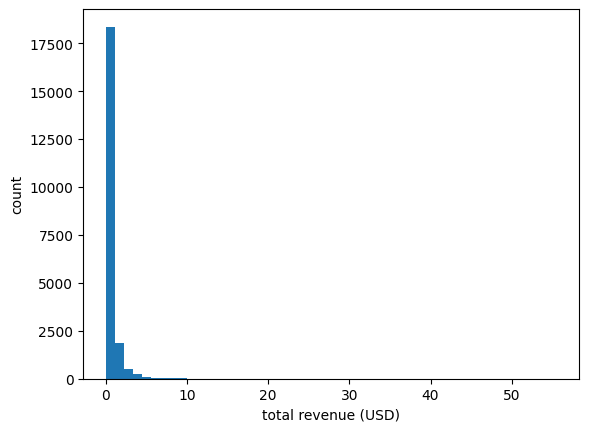

In [60]:
# extract event_count and total_revenue from events
events_models_df[['event_count', 'total_revenue']] = events_models_df['events'].apply(parse_events)

# examine the total_revenue column (event_count column is not used in this analysis)
print(f'Minimum non-zero value of total_revenue: {round(events_models_df.loc[events_models_df['total_revenue'] != 0, 'total_revenue'].min(), 6)}')
print(f'Maximum value of total_revenue: {round(events_models_df['total_revenue'].max(), 6)}')

# plot a histogram of total_revenue values
plt.figure()
plt.hist(events_models_df.loc[(events_models_df['total_revenue'] != 0), 'total_revenue'], bins = 50)
plt.xlabel('total revenue (USD)')
plt.ylabel('count')
plt.show()

The distribution is heavily skewed. However, the most extreme values should not be disregarded, as they are important from the business perspective. A good solution could be to take the logarithm of the values.

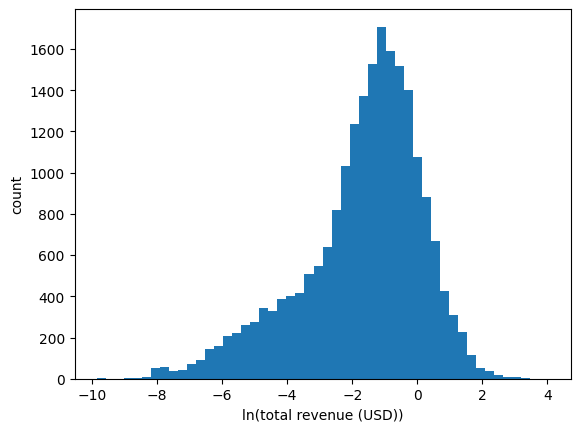

In [61]:
# plot a histogram of log(total_revenue) values
plt.figure()
plt.hist(np.log(events_models_df.loc[events_models_df['total_revenue'] != 0, 'total_revenue']), bins = 50)
plt.xlabel('ln(total revenue (USD))')
plt.ylabel('count')
plt.show()

The histogram confirms the above hypothesis. Therefore, the logarithm of the total revenue will be used as the regression label.

In [62]:
# define labels:
# has_events for binary classification
events_models_df['has_events'] = (events_models_df['events'].str.len() > 2).astype('Int32')
# log of total revenue for regression
events_models_df['log_total_revenue'] = np.where(events_models_df['total_revenue'] > 0, 
                                                 np.log(events_models_df['total_revenue']), 0.0)
# other labels / label combinations were tried but no performance improvement was achieved

In [63]:
# log the features and impute all values missing due to the lack of coverage
events_models_non_feature_cols = ['hashed_aaid', 'd', 'events', 'has_events', 'event_count', 
                                  'total_revenue', 'log_total_revenue']
events_models_feature_cols = [col for col in events_models_df.columns if (col not in events_models_non_feature_cols) and 
                           (not col.endswith('frac'))]
events_models_df[events_models_feature_cols] = np.log1p(events_models_df[events_models_feature_cols])

events_models_df.fillna(-1.0, inplace = True)

In [64]:
# add app counts to the feature set
cols_to_merge = ['hashed_aaid'] + app_count_cols
events_models_df = events_models_df.merge(install_model_df[cols_to_merge], on = 'hashed_aaid', how = 'left')

The modelling approach for this part of the competition is as follows:
* the events_models_df is split into train and test sets stratifying by 'has_events' - this split is applied for both models, with the test set held out for a comparison of user ordering using the has events model only vs using both models,
* from the train set, separate sets for the classification and the regression are derived,
* the classification set is scaled using the standard scaler, as the has events model is a logistic regression,
* LightGBM was also tried for the purpose, but was not found to improve the performance,
* the performance of the classification model is assessed using cross-validation (within the train set)
* the regression set filters out users which have not had any events,
* it was first fitted with ridge regression, then with LightGBM which brought an improvement in performance, measured using the Spearman correlation coefficient,
* the choice of the metric was dictated by the fact that the focus of the competition is on the order of the users, not the ad revenue values themselves,
* similarly to the install model, a grid search was performed over 12 combinations of hyperparameters, using a validation set extracted from the train set to assess the performance,
* both models (classifier and regressor) are fitted on their whole training sets,
* classification and regression predictions are made on the common test set, and then multiplied together to obtain 2-component scores,
* test set is ordered by the probability of having events alone, then by the 2-component score,
* for both cases the sum of total ad revenue for the top 1% (approximately the fraction of candidate users expected for submission among all candidate users) of users is computed and compared to determine whether the ad revenue model should be used or not.

In [65]:
train_df, test_df = train_test_split(
    events_models_df,
    test_size = 0.1, # the test set here is used to compare user ordering using the has events model only vs both models  
    stratify = events_models_df['has_events'],
    random_state = 42
)

# data sets for the has events classification
X_train_clf = train_df.drop(columns = events_models_non_feature_cols)
y_train_clf = train_df['has_events']
X_test_clf = test_df.drop(columns = events_models_non_feature_cols)
y_test_clf = test_df['has_events']

# label imbalance
y_train_clf.value_counts()/y_train_clf.value_counts().sum()

has_events
0    0.938417
1    0.061583
Name: count, dtype: Float64

In [66]:
# scale features - remove the mean and scale to unit variance
scaler = StandardScaler()
X_train_clf_scaled = pd.DataFrame(scaler.fit_transform(X_train_clf))
X_test_clf_scaled = pd.DataFrame(scaler.transform(X_test_clf))
X_train_clf_scaled.index = X_train_clf.index.values
X_test_clf_scaled.index = X_test_clf.index.values

In [67]:
# different values of C and solvers did not improve the performance
has_events_model = LogisticRegression(C = 1.0, class_weight = 'balanced', solver = 'lbfgs', max_iter = 200, random_state = 42)
cross_val_scores_clf = cross_val_score(has_events_model, X_train_clf_scaled, y_train_clf, scoring = 'average_precision')
print(f'Cross-validated AUPRC scores: {np.round(cross_val_scores_clf, 3)}')
print(f'Mean cross-validated AUPRC score: {np.round(cross_val_scores_clf.mean(), 3)}')

Cross-validated AUPRC scores: [0.117 0.115 0.117 0.116 0.12 ]
Mean cross-validated AUPRC score: 0.117


In [68]:
# define a custom metric for the regression model
def spearman_scorer(y_true, y_pred):
    return spearmanr(y_true, y_pred).correlation
    
spearman = make_scorer(spearman_scorer, greater_is_better = True)

In [69]:
# data set for the ad revenue model
X_train_reg = train_df.loc[train_df['has_events'] == 1.0].drop(columns = events_models_non_feature_cols)
y_train_reg = train_df.loc[train_df['has_events'] == 1.0, 'log_total_revenue']

The commented out code below was used for the hyperparameter tuning. Again, the chosen sets are 'best guesses' given the dimensions of the train set. The results were as follows:
* Run 01 | valid Spearman coefficient=0.346 | best_iter=158 | cap=small/samp=mild/reg=medium
* Run 02 | valid Spearman coefficient=0.344 | best_iter=182 | cap=small/samp=mild/reg=strong
* Run 03 | valid Spearman coefficient=0.348 | best_iter=184 | cap=small/samp=strong/reg=medium
* Run 04 | valid Spearman coefficient=0.348 | best_iter=253 | cap=small/samp=strong/reg=strong
* Run 05 | valid Spearman coefficient=0.349 | best_iter=095 | cap=medium/samp=mild/reg=medium
* Run 06 | valid Spearman coefficient=0.346 | best_iter=098 | cap=medium/samp=mild/reg=strong
* Run 07 | valid Spearman coefficient=0.346 | best_iter=138 | cap=medium/samp=strong/reg=medium
* Run 08 | valid Spearman coefficient=0.347 | best_iter=107 | cap=medium/samp=strong/reg=strong
* Run 09 | valid Spearman coefficient=0.345 | best_iter=083 | cap=large/samp=mild/reg=medium
* Run 10 | valid Spearman coefficient=0.347 | best_iter=099 | cap=large/samp=mild/reg=strong
* Run 11 | valid Spearman coefficient=0.350 | best_iter=109 | cap=large/samp=strong/reg=medium
* Run 12 | valid Spearman coefficient=0.348 | best_iter=152 | cap=large/samp=strong/reg=strong

Parameters from Run 11 were used for the final training.

In [70]:
# X_train_lgbm, X_valid_lgbm, y_train_lgbm, y_valid_lgbm = train_test_split(
#     X_train_reg,
#     y_train_reg,
#     test_size = 0.2,
#     random_state = 42
# )

# fixed = {
#     'learning_rate': 0.05,
#     'n_estimators': 4000,
#     'early_stop_rounds': 150,
# }

# param_tree = {
#     'capacity': {
#         'small':  {'num_leaves': 15,  'min_child_samples': 80},
#         'medium': {'num_leaves': 31,  'min_child_samples': 40},
#         'large':  {'num_leaves': 63, 'min_child_samples': 20},
#     },
#     'sampling': {
#         'mild':   {'subsample': 0.9, 'subsample_freq': 1, 'colsample_bytree': 0.9},
#         'strong': {'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 0.7},
#     },
#     'regularization': {
#         'medium': {'reg_lambda': 3.0,  'reg_alpha': 0.0, 'min_split_gain': 0.0},
#         'strong': {'reg_lambda': 10.0, 'reg_alpha': 0.0, 'min_split_gain': 0.0},
#     },
# }

# results = []
# run = 0

# for cap, samp, regu in product(
#     param_tree['capacity'].keys(),
#     param_tree['sampling'].keys(),
#     param_tree['regularization'].keys()
# ):
#     run += 1
#     cfg = {}
#     cfg.update(param_tree['capacity'][cap])
#     cfg.update(param_tree['sampling'][samp])
#     cfg.update(param_tree['regularization'][regu])

#     ad_revenue_model = LGBMRegressor(
#         objective = 'regression',
#         random_state = 42,
#         n_jobs = -1,
#         learning_rate = fixed['learning_rate'],
#         n_estimators = fixed['n_estimators'],
#         verbosity = -1,
#         **cfg
#     )

#     ad_revenue_model.fit(
#         X_train_lgbm, y_train_lgbm,
#         eval_set = [(X_valid_lgbm, y_valid_lgbm)],
#         eval_metric = 'l2',
#         callbacks = [early_stopping(stopping_rounds = fixed['early_stop_rounds'], verbose = False)]
#     )

#     pred_valid = ad_revenue_model.predict(X_valid_lgbm)
#     spearman_coef = spearman_scorer(y_valid_lgbm, pred_valid)

#     results.append({
#         'run': run,
#         'spearman_valid': spearman_coef,
#         'best_iter': getattr(ad_revenue_model, 'best_iteration_', None),
#         'capacity': cap,
#         'sampling': samp,
#         'regularization': regu,
#         **cfg
#     })

#     print(f'Run {run:02d} | valid Spearman coefficient={spearman_coef:.3f} | best_iter={getattr(ad_revenue_model, "best_iteration_", None):03d} | cap={cap}/samp={samp}/reg={regu}')

In [71]:
# Run 11 parameters
params = {
    'learning_rate': 0.05,
    'n_estimators': 109,
    'num_leaves': 63,
    'min_child_samples': 20,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.7,
    'reg_lambda': 3.0,
    'reg_alpha': 0.0,
    'min_split_gain': 0.0
}

ad_revenue_model = LGBMRegressor(
    objective = 'regression',
    random_state = 42,
    n_jobs = -1,
    verbosity = -1,
    **params,
)

In [72]:
# fit both models on their respective train sets, predict on the common test set
has_events_model.fit(X_train_clf_scaled, y_train_clf)
y_pred_proba_test_clf = has_events_model.predict_proba(X_test_clf_scaled)[:, 1]

ad_revenue_model.fit(X_train_reg, y_train_reg)
y_pred_test_reg = ad_revenue_model.predict(X_test_clf) # the test set also containing users without events

The below check was deemed necessary due to the performance of both models. The classification model achieved 11.7% AUPRC, which is not irrelevant given the 6.2% of the positives, but it raises a question of how noisy the predictions are. The regression model achieved correlation coefficient of 0.35, which leads to similar considerations.

In [73]:
# compute the sum of total ad revenue for the top 1% of users for the case where ordering is based only on has_events_proba
# and for the case where it is based on both has_events_proba and ad_revenue_pred 
# and compare to determine whether the ad revenue model should be used or not
test_df['has_events_proba'] = y_pred_proba_test_clf
test_df['ad_revenue_pred'] = np.exp(y_pred_test_reg)
test_df['test_score'] = test_df['has_events_proba'] * test_df['ad_revenue_pred']

one_hundredth = int(len(test_df)/100) # approximately submission set size / candidate set size

sum_by_proba = test_df.sort_values(by = 'has_events_proba', ascending = False).head(one_hundredth)['total_revenue'].sum()
sum_by_score = test_df.sort_values(by = 'test_score', ascending = False).head(one_hundredth)['total_revenue'].sum()

print(f'Sum of ad revenue when ordering by the probability of having events alone: {round(sum_by_proba, 2)} USD')
print(f'Sum of ad revenue when ordering by the probability of having events multiplied by the ad revenue prediction: {round(sum_by_score, 2)} USD')

Sum of ad revenue when ordering by the probability of having events alone: 55.74 USD
Sum of ad revenue when ordering by the probability of having events multiplied by the ad revenue prediction: 69.51 USD


Based on the above, the decision to include the ad revenue model predictions in the final scoring was made. However, it should be noted that while the model is able to discern patterns leading to user ordering considerably better than random, its predictions of the actual ad revenue values certainly leave room for improvement.

## Predictions
Candidate set preparation and running it through the models.

In [74]:
# perform (almost) the same processing as for the training sets
chunksize = 100_000
candidate_chunks = []

install_model_candidate_cols = [col for col in install_model_cols if col not in ['hashed_aaid', 'install', 'd']]
events_models_candidate_cols = [col for col in events_models_cols if col not in ['hashed_aaid', 'events', 'd']]
candidate_feature_cols = list(set(install_model_candidate_cols).union(set(events_models_candidate_cols)))

pseudo_cols = [col for col in install_model_candidate_cols if 'pseudo' in col]
metrics = list(set(install_metrics).union(set(events_metrics)))
metrics_for_apps = ['ohh_installs', 'ohh_quarters_active', 'uwu_quarters_active', 'bar_uninstalls']

for chunk in pd.read_csv(candidate_path, dtype = types, chunksize = chunksize):
    
    candidate_chunk = chunk[['hashed_aaid']].copy()
    for k, cols in family_cols.items():
        candidate_chunk[f'{k}_non_null_frac'] = (1.0 - chunk[cols].isna().mean(axis=1)).astype('float32')
    candidate_chunk[candidate_feature_cols] = chunk[candidate_feature_cols]

    mask = candidate_chunk['ohh_non_null_frac'].ne(0.0)
    candidate_chunk.loc[mask, pseudo_cols] = candidate_chunk.loc[mask, pseudo_cols].fillna(999999.0)

    temp = [col for col in pseudo_cols if 'board_card' not in col and 'brain_game' not in col]
    candidate_chunk['ohh_pseudo_install_time_diff_rest_d56'] = candidate_chunk[temp].min(axis=1)
    candidate_chunk.drop(columns = temp, inplace = True)

    for k, cols in family_cols.items():
        frac_col = f'{k}_non_null_frac'
        cols = [col for col in cols if col in candidate_chunk.columns]
        mask = candidate_chunk[frac_col].ne(0.0)
        candidate_chunk.loc[mask, cols] = candidate_chunk.loc[mask, cols].fillna(0.0)

    for metric in metrics:
        for dX in ['d3', 'd7', 'd28', 'd56', 'd60', 'd180']:
            cols_to_sum = [col for col in candidate_chunk.columns if (metric in col) and (dX in col) and 
                           ('brain_game' not in col) and ('board_card' not in col)]
            if len(cols_to_sum) > 0:
                agg_name = metric + '_rest_' + dX
                candidate_chunk[agg_name] = candidate_chunk[cols_to_sum].sum(axis = 1)
                if (metric not in metrics_for_apps) or (dX not in ['d28', 'd180']):
                # metrics for apps are needed to impute missing values in app counts    
                    candidate_chunk.drop(columns = cols_to_sum, inplace = True)  
    
    candidate_chunks.append(candidate_chunk)
    del chunk, candidate_chunk
    gc.collect()

metrics.remove('uwu_installs')

candidate_df = pd.concat(candidate_chunks, ignore_index = True)

pseudo_cols = [col for col in candidate_df.columns if 'pseudo' in col] # now only contains 3 cols
# use the value from the training set
candidate_df[pseudo_cols] = candidate_df[pseudo_cols] - min_pseudo_install_time_diff 
candidate_df[pseudo_cols] = candidate_df[pseudo_cols].clip(lower = 0) # clip if any negatives left

candidate_df[f'uwu_total_quarters_active_d28m3'] = (
    candidate_df[f'uwu_total_quarters_active_d28'] - candidate_df[f'uwu_total_quarters_active_d3']
)
candidate_df[f'uwu_total_quarters_active_d7m3'] = (
    candidate_df[f'uwu_total_quarters_active_d7'] - candidate_df[f'uwu_total_quarters_active_d3']
)
candidate_df[f'ohh_total_quarters_active_d28m3'] = (
    candidate_df[f'ohh_total_quarters_active_d28'] - candidate_df[f'ohh_total_quarters_active_d3']
)
candidate_df[f'ohh_total_quarters_active_d7m3'] = (
    candidate_df[f'ohh_total_quarters_active_d7'] - candidate_df[f'ohh_total_quarters_active_d3']
)
candidate_df.drop(columns = ['uwu_total_quarters_active_d28','uwu_total_quarters_active_d7', 'uwu_total_quarters_active_d3',
                             'ohh_total_quarters_active_d28', 'ohh_total_quarters_active_d7', 'ohh_total_quarters_active_d3'],
                  inplace = True)

for category in ['rest', 'brain_game', 'board_card']:
    candidate_df[f'bar_uninstalls_{category}_d180m3'] = (
        candidate_df[f'bar_uninstalls_{category}_d180'] - candidate_df[f'bar_uninstalls_{category}_d3']
    )
    for metric in metrics:
        candidate_df[f'{metric}_{category}_d28m3'] = (
            candidate_df[f'{metric}_{category}_d28'] - candidate_df[f'{metric}_{category}_d3']
        )
        candidate_df[f'{metric}_{category}_d7m3'] = (
            candidate_df[f'{metric}_{category}_d7'] - candidate_df[f'{metric}_{category}_d3']
        )
        if (category == 'rest') or (metric not in metrics_for_apps):
        # metrics for apps are needed to impute missing values in app counts 
            candidate_df.drop(columns = [f'{metric}_{category}_d28', f'{metric}_{category}_d7', 
                                         f'{metric}_{category}_d3'], inplace = True)
        else:
            candidate_df.drop(columns = [f'{metric}_{category}_d7', f'{metric}_{category}_d3'], inplace = True)

candidate_df.drop(columns = ['bar_uninstalls_rest_d180'], inplace = True)

engineer_features(candidate_df, False)

app_candidate_df['app_list'] = app_candidate_df['app_ids'].fillna('').str.split(',')
id_app_long_df = app_candidate_df[['hashed_aaid', 'app_list']].explode('app_list').rename(columns={'app_list': 'app_id'})
id_app_long_df['app_id'] = pd.to_numeric(id_app_long_df['app_id'].str.strip(), errors = 'coerce').astype('Int32')
id_app_long_df = id_app_long_df.merge(mapping_df, on = 'app_id', how = 'left').dropna(subset = ['category'])

cat_counts_df = (id_app_long_df.groupby(['hashed_aaid', 'category']).size()
                               .unstack(fill_value = 0).add_prefix('app_count_').reset_index())
count_cols = [col for col in cat_counts_df.columns if col.startswith('app_count_')]
cat_counts_df[count_cols] = cat_counts_df[count_cols].astype('float32')

# for candidates, merge_asof is not needed as hashed_aaids do not repeat
candidate_df = candidate_df.merge(cat_counts_df, on = 'hashed_aaid', how = 'left')

del candidate_chunks
del id_app_long_df
del cat_counts_df

gc.collect()

candidate_categories = [col.replace('app_count_', '') for col in candidate_df.columns if 'app_count' in col]
# (candidate_categories == categories) = True

candidate_df['uwu_sum_unique_apps_for_apps_d28'] = candidate_df['uwu_sum_unique_apps_d28']
cols_for_apps = [col for col in candidate_df.columns if ('ohh_installs' in col and col.endswith('d28')) or
                ('ohh_quarters_active' in col and col.endswith('d28')) or
                 ('uwu_quarters_active' in col and col.endswith('d28')) or
                ('bar_uninstalls' in col and col.endswith('d180')) or (col == 'uwu_sum_unique_apps_for_apps_d28')]
candidate_df[cols_for_apps] = candidate_df[cols_for_apps].fillna(-1.0)

unlabeled = candidate_df['app_count_brain_game'].isna()

for category in candidate_categories:
    cols_for_apps = [f'ohh_quarters_active_{category}_d28', f'uwu_quarters_active_{category}_d28', 
                     f'bar_uninstalls_{category}_d180', f'ohh_installs_{category}_d28', 'uwu_sum_unique_apps_for_apps_d28']
    y_col = f'app_count_{category}'

    Xu = candidate_df.loc[unlabeled, cols_for_apps].to_numpy(dtype = np.float32, copy = False)
    Xu1 = np.column_stack([np.ones((Xu.shape[0], 1), dtype = Xu.dtype), Xu])

    # make predictions using the coefficients determined on the training set
    pred = Xu1 @ b
    candidate_df.loc[unlabeled, y_col] = pred

    candidate_df.drop(columns = cols_for_apps[:-1], inplace = True)

candidate_df.drop(columns = ['uwu_sum_unique_apps_for_apps_d28'], inplace = True)

del unlabeled
del pred
del Xu
del Xu1

gc.collect()

candidate_df[count_cols] = candidate_df[count_cols].clip(lower = 0)

candidate_feature_cols = [col for col in candidate_df.columns if (col != 'hashed_aaid') and (not col.endswith('frac'))]
candidate_df[candidate_feature_cols] = np.log1p(candidate_df[candidate_feature_cols])

candidate_df.fillna(-1.0, inplace = True)

In [75]:
# out
count_cols == app_count_cols

True

In [76]:
# derive separate data sets for the install model and the other two models
install_model_X_train_cols = [col for col in install_model_df if col not in ['hashed_aaid', 'install', 'd']]
install_model_X_predict = candidate_df[install_model_X_train_cols]
events_models_X_train_cols = [col for col in events_models_df if col not in events_models_non_feature_cols]
events_models_X_predict = candidate_df[events_models_X_train_cols]

In [77]:
# scale using scaler fitted on the training data
events_models_X_predict_scaled = pd.DataFrame(scaler.transform(events_models_X_predict))
events_models_X_predict_scaled.index = events_models_X_predict.index.values

In [78]:
# make predictions
y_install_proba_predict = install_model.predict_proba(install_model_X_predict)[:, 1]
y_has_events_proba_predict = has_events_model.predict_proba(events_models_X_predict_scaled)[:, 1]
y_ad_reve_predict = ad_revenue_model.predict(events_models_X_predict)

In [79]:
# add to the candidate_df
candidate_df['install_proba'] = y_install_proba_predict
candidate_df['has_events_proba'] = y_has_events_proba_predict
candidate_df['ad_revenue_pred'] = np.exp(y_ad_reve_predict)
# compute the score
candidate_df['candidate_score'] = candidate_df['install_proba'] * candidate_df['has_events_proba'] * candidate_df['ad_revenue_pred']

# inspect the output
candidate_df.sort_values(by = 'candidate_score', ascending = False).head(10_000)

,hashed_aaid,uwu_non_null_frac,ohh_non_null_frac,bar_non_null_frac,foo_non_null_frac,bar_uninstalls_transportation_d28,bar_uninstalls_health_d28,bar_uninstalls_travel_d28,bar_uninstalls_entertainment_d28,bar_uninstalls_education_d28,...,app_count_sport,app_count_strategy,app_count_transportation,app_count_travel,app_count_utilities,app_count_weather,install_proba,has_events_proba,ad_revenue_pred,candidate_score
429241,148a2960d79cdafa48fee2b5bcbe5c9e530d5ea49fc1fc9ca895090ee8b81863,0.043243,0.175620,0.085106,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.693147,1.098612,2.397895,2.890372,1.098612,0.996235,0.778055,0.805698,0.624517
338503,85db74fd07600294d6c07ff8d599b87fa9432891c6816580bc69b782970e4405,0.000000,0.000000,0.397163,0.000000,0.0,0.0,0.0,0.693147,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,0.995949,0.905882,0.632961,0.571065
63338,adf21e8865406cb9e77d58257ace21cdc65c0531e62d36f206ceb3b987c2bdf5,0.000000,0.000000,0.198582,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,1.098612,1.098612,0.915385,0.849393,0.718103,0.558341
956572,9933b382d2d349016f9ddb87dafdd9d67ad39d1748c3270e9e6de876f588ff89,0.064865,0.105372,0.191489,0.000000,0.0,0.0,0.0,0.693147,0.0,...,0.693147,0.000000,0.693147,0.693147,2.197225,0.693147,0.980491,0.852901,0.665853,0.556827
440678,adc5c908ea1194daed61dbe94e26f8c7fd4a5cd9ecd635b0d98893a95ba8baa3,0.072973,0.146694,0.113475,0.000000,0.0,0.0,0.0,0.000000,0.0,...,2.302585,0.000000,0.693147,2.079442,3.258096,1.386294,0.987840,0.725462,0.744071,0.533232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505657,8cc67a81fef03bf515267515f236d1f7f5cd67496fceb98159fc5ac9fcd1b356,0.067568,0.078512,0.028369,0.062500,0.0,0.0,0.0,0.000000,0.0,...,1.098612,0.000000,0.000000,0.693147,2.302585,0.693147,0.723226,0.511497,0.229898,0.085046
751344,fdb0c14fd108e6f76bdc94bfd840667950b086d68af4382345244e0b50db2e8d,0.041892,0.002066,0.000000,0.000000,-1.0,-1.0,-1.0,-1.000000,-1.0,...,1.609438,0.000000,0.693147,1.386294,2.197225,0.693147,0.810531,0.336146,0.312124,0.085040
588590,2be371753366067015cb917ff4d70af1c9cd11b93eeb283c0583ba8fb1cce3ec,0.062162,0.000000,0.000000,0.035714,-1.0,-1.0,-1.0,-1.000000,-1.0,...,0.606686,0.606686,0.606686,0.606686,0.606686,0.606686,0.668602,0.688629,0.184701,0.085040
813690,ad98902d9a594c514564a9baf8bd4b46317cf1a26051c9b7cb62fb71d72a826c,0.021622,0.004132,0.000000,0.000000,-1.0,-1.0,-1.0,-1.000000,-1.0,...,0.000000,0.000000,0.000000,0.000000,1.386294,0.693147,0.854519,0.519066,0.191717,0.085036


In [80]:
# convert into expected format
submission_df = candidate_df.sort_values(by = 'candidate_score', ascending = False).head(10_000)[['hashed_aaid']]
submission_df['prediction'] = 0
# save to csv
submission_df.to_csv('submission_Wincenty_Szymura.csv', index = False)